========================================================
# Airline Classification  Modeling with Sentiment Tweets
========================================================


In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pyarrow.lib import Device
from wordcloud import WordCloud
import re
import copy

from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
from gensim.models import FastText

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from gensim.models.fasttext import load_facebook_model
from gensim.models import KeyedVectors
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [49]:
# In this section we will create the main functions that we are gonna use


# The following functions are for EDA and plotting -----------------
def load_data(path):
    """
    This function loads the data from the csv file
    Params:
        path: path to the csv file
    Return:
        df: dataframe with the data
    """
    df = pd.read_csv(path)
    print(f'Data shape: instances: {df.shape[0]}, features: {df.shape[1]}')
    print(f'Data columns: {df.columns.to_list()}')
    return df


def plot_data(x, y, feature, colors):
    """
    This function create two plots with the selected data and returns two plots with the value counts
    Params:
        col: feature name
    Return:
         bar chart
         pie chart
    """
    fig, axes = plt.subplots(1, 2, figsize = (13, 5))

    # create a bar chart
    axes[0].bar(x, y, color = colors[:len(x)])
    axes[0].set_title(f'{feature}: Count')
    axes[0].set_xlabel(f'{feature}')
    axes[0].set_ylabel('Count')

    # create a pie chart
    axes[1].pie(y, labels = x, autopct='%1.1f%%', colors = colors[:len(x)])
    axes[1].set_title(f'{feature}: Distribution (%)')
    plt.tight_layout()

    plt.show()


# The following functions are for Text preprocessing and cleaning -----------------

def clean_tweet(text):
    """
    This function remove noise tokens
    Params:
        text: text to clean
    Return:
        cleaned text
        """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text) #removes urls
    text = re.sub(r'@\w+', '', text) #removes @
    text = re.sub(r'#', '', text) #removes hashtags
    text = re.sub(r'&\w+;', '', text) #removes html
    text = re.sub(r'[^a-z\s]', '', text) # removes punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    """
    This function remove other characters, tokenize, remove stopwords and lemmatise
    Params:
        text: text to tokenize
    Return:
        the list of tokens
    """
    text = clean_tweet(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return tokens



def preprocess_corpus(texts):
    """
    This function applies the full pipeline to each tweet
    Params:
        texts:
    Return:
        a cleaned string series
    """
    return texts.map(lambda t: ' '.join(tokenize(t)))


def vectorize_texts(train_texts, val_texts,test_texts, method ='tfidf', max_features = 15000):
        """
    Converts text  into numerical feature.
    Args:
        train_texts, val_texts, test_texts: arrays of cleaned strings.
        method: 'tfidf'
        max_features: vocabulary size for TF-IDF.

    Returns:
        X_train, X_val, X_test as arrays.
    """
        if method == 'tfidf':
            print('Vectorizing text with TF-IDF')
            vectorizer = TfidfVectorizer(max_features = max_features, ngram_range = (1, 2), sublinear_tf = True, min_df = 2)
            X_tr = vectorizer.fit_transform(train_texts).toarray().astype('float32')
            X_v  = vectorizer.transform(val_texts).toarray().astype('float32')
            X_te = vectorizer.transform(test_texts).toarray().astype('float32')
        else:
            raise ValueError(f'This method does not exist {method}')
        return X_tr, X_v, X_te


class ANN(nn.Module):
    """ ANN MODULE FOR TRAINING"""

    def __init__(self, input_dim, hidden_dim1, hidden_dim2, hidden_dim3, output_dim, dropout_p1 = 0.4, dropout_p2 = 0.3, dropout_p3 = 0.2):
        """
        Args:
            input_dim   (int): Number of input features (TF-IDF vocab size).
            hidden_dim1 (int): Units in the first hidden layer.
            hidden_dim2 (int): Units in the second hidden layer.
            hidden_dim3 (int): Units in the third hidden layer.
            output_dim  (int): Number of output classes (3).
            dropout_p1-3 (float): Dropout probabilities per layer.
        """
        super(ANN, self).__init__()

        # Layers
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, output_dim)

        # Batch normalization
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)
        self.bn3 = nn.BatchNorm1d(hidden_dim3)

        # Dropout layers
        self.dropout1 = nn.Dropout(p = dropout_p1)
        self.dropout2 = nn.Dropout(p = dropout_p2)
        self.dropout3 = nn.Dropout(p = dropout_p3)

    def forward(self, x):
        """
        This function performs the forward pass of the ANN
        """
        # hidden layer 1
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        # hidden layer 2
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        # hidden layer 3
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)

        # output layer
        x = self.fc4(x)

        return x


class EarlyStopping:
    """ Functions to support the training"""

    def __init__(self, patience = 5, min_delta = 0.0):
        """If validation loss does not improve the training will early stop"""
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = None

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > (self.best_loss - self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


def plot_losses(train_losses, val_losses, figsize = (10, 5), show_plot = True):
    """
    This function plots the training and validation loss curves
    Args:
        train_losses: training loss per epoch.
        val_losses: validation loss per epoch.
        figsize: figure size.
        show_plot: if you want to show the plot
    """
    fig, ax = plt.subplots(figsize = figsize)
    ax.plot(train_losses, label = 'Training Loss', color = 'blue')
    ax.plot(val_losses, label = 'Validation Loss', color = 'red')
    ax.set_title('Training and Validation Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()
    if show_plot:
        plt.show()
    plt.close(fig)


def ensure_dir_exists(file_path: str) -> None:
    """
    Create directory for a file path if it does not exist.
    """
    directory = os.path.dirname(file_path)
    if directory and not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs = 200, device = 'cpu', patience = 5, save_path='checkpoints/best_model.pt'):
    """
    This function trains the model with early stopping

    Args:
        model: the neural network
        train_loader: training data.
        val_loader: Validation data.
        criterion: Loss function
        optimizer: the optimizer
        num_epochs: maximum training epochs.
        device: 'cpu'
        patience: early stopping
    Returns:
        model, train_losses, val_losses, train_accuracies, val_accuraciess
        """

    early_stopping = EarlyStopping(patience=patience, min_delta=0.0001)

    train_losses, val_losses         = [], []
    train_accuracies, val_accuracies = [], []

    best_val_loss       = float('inf')
    best_model_weights  = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):

        # Training
        model.train()
        running_loss  = 0.0
        correct_preds = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs.float())
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss  += loss.item() * inputs.size(0)
            _, predicted   = torch.max(outputs, dim=1)
            correct_preds += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc  = correct_preds / total_samples
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # Validation
        model.eval()
        running_val_loss  = 0.0
        correct_val_preds = 0
        val_samples       = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs          = model(inputs.float())
                loss             = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted      = torch.max(outputs, dim=1)
                correct_val_preds += (predicted == labels).sum().item()
                val_samples       += labels.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc  = correct_val_preds / val_samples
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # Print epoch metrics
        print(f'Epoch [{epoch+1}/{num_epochs}] | '
              f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | '
              f'Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}')

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss      = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

            ensure_dir_exists(save_path)
            torch.save({
                'epoch':              epoch + 1,
                'model_state_dict':   model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss':           epoch_val_loss,
            }, save_path)
            print(f'Model improved. Saved to {save_path}')

        # Early stopping check
        early_stopping(epoch_val_loss)
        if early_stopping.early_stop:
            print('Early stopping')
            break

    # Restore best weights before returning
    model.load_state_dict(best_model_weights)
    return model, train_losses, val_losses, train_accuracies, val_accuracies
















In [3]:
df = load_data(r'../data/Tweets.csv')
df.head(3)

Data shape: instances: 14640, features: 15
Data columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


## Exploratory Data Analysis

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  ob

<Axes: >

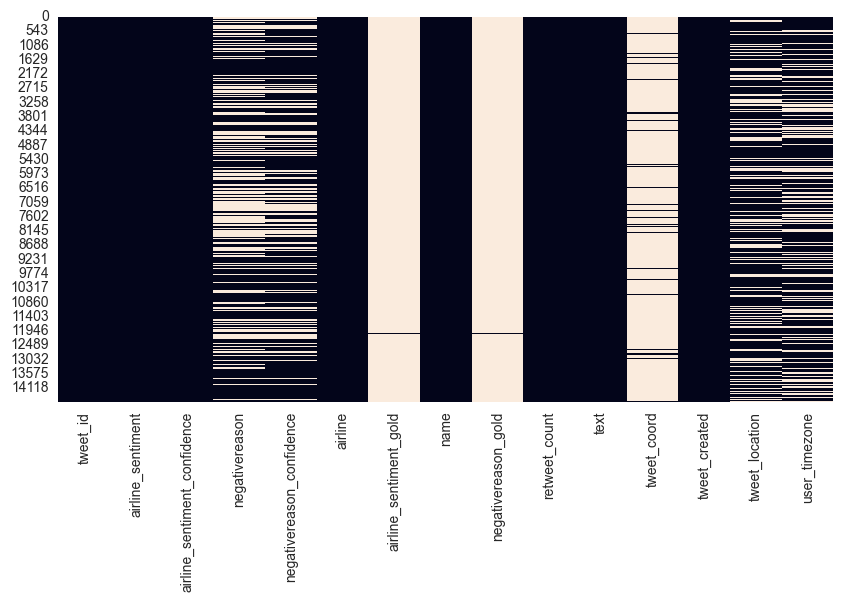

In [4]:
# Inspect the data and check for missing values

print('Data Info: ')
print(df.info())
print(f'\nMissing Values:')
print(df.isnull().sum())
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)

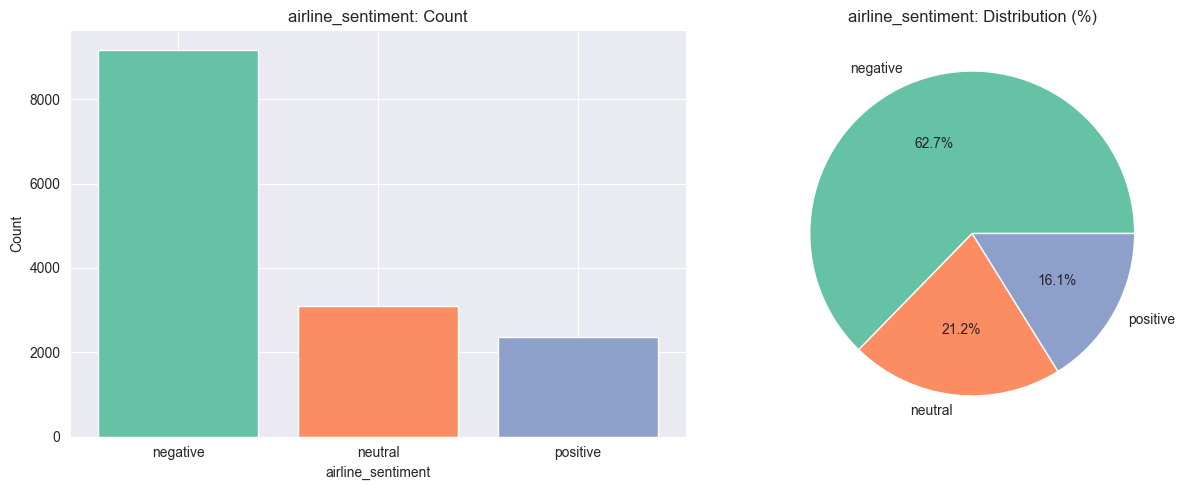

In [5]:
# Let's plot the sentiment tweets to have a look

x, y = df['airline_sentiment'].value_counts().index, df['airline_sentiment'].value_counts().values
colors = sns.color_palette("Set2")

plot_data(x, y, 'airline_sentiment', colors)

# We can see that the vast majority of tweets are negative
# The data are imbalanced


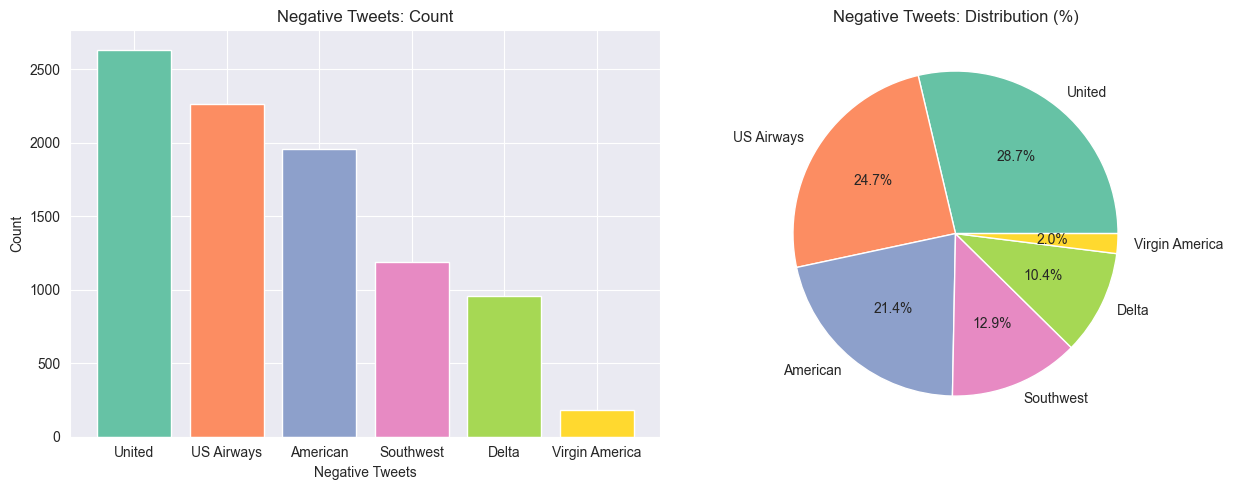

In [6]:
# Let's find out which airline has the most negative tweets

df_sent = df.groupby('airline')['airline_sentiment'].value_counts().reset_index(name = 'count')

# Check the negative tweets for each airline
negatives = df_sent[df_sent['airline_sentiment'] == 'negative'].sort_values('count', ascending=False)

plot_data(negatives['airline'], negatives['count'], 'Negative Tweets', colors)


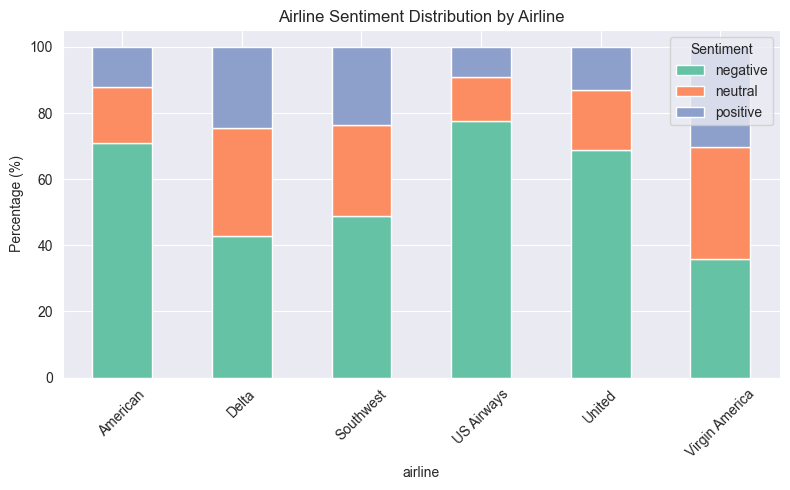

In [7]:
# Quick view on sentiment distribution per airline

stacked = (df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)[['negative', 'neutral', 'positive']])
stacked = stacked.div(stacked.sum(axis=1), axis=0) * 100

stacked.plot(kind = 'bar', stacked = True, figsize = (8,5), color = colors)
plt.ylabel('Percentage (%)')
plt.title('Airline Sentiment Distribution by Airline')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

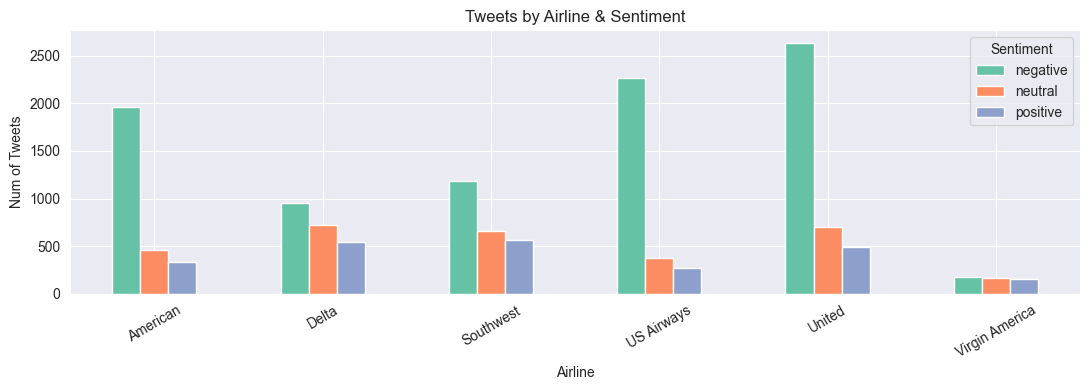

In [8]:
# Check the tweets of each sentiment for each airline

pivot = (df.groupby(['airline','airline_sentiment']).size().unstack(fill_value = 0))
pivot.plot(kind = 'bar', figsize = (11,4), color = colors)
plt.title('Tweets by Airline & Sentiment')
plt.xlabel('Airline')
plt.ylabel('Num of Tweets')
plt.xticks(rotation=30)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

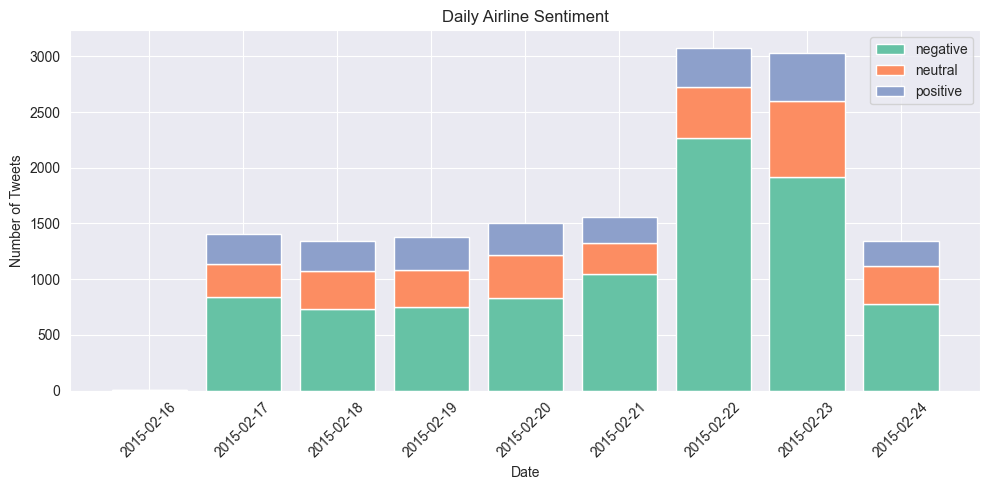

In [9]:
# Let's analyze the daily tweets

df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['date'] = df['tweet_created'].dt.date
df['hour'] = df['tweet_created'].dt.hour
df['day_of_week'] = df['tweet_created'].dt.day_name()
df['day_num'] = df['tweet_created'].dt.dayofweek

daily_sent = (df.groupby(['date', 'airline_sentiment']).size().unstack(fill_value=0))
daily_sent.index = pd.to_datetime(daily_sent.index)

# Plot the daily tweets
x = np.arange(len(daily_sent))
bottom = np.zeros(len(daily_sent))

plt.figure(figsize=(10,5))
for i, col in enumerate(daily_sent.columns):
    plt.bar(x, daily_sent[col], bottom=bottom, color=colors[i], label=col)
    bottom += daily_sent[col]

plt.xticks(x, daily_sent.index.date, rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('Daily Airline Sentiment')
plt.legend()
plt.tight_layout()
plt.show()

# In 22, 23 and 24/02 were the most negative tweets

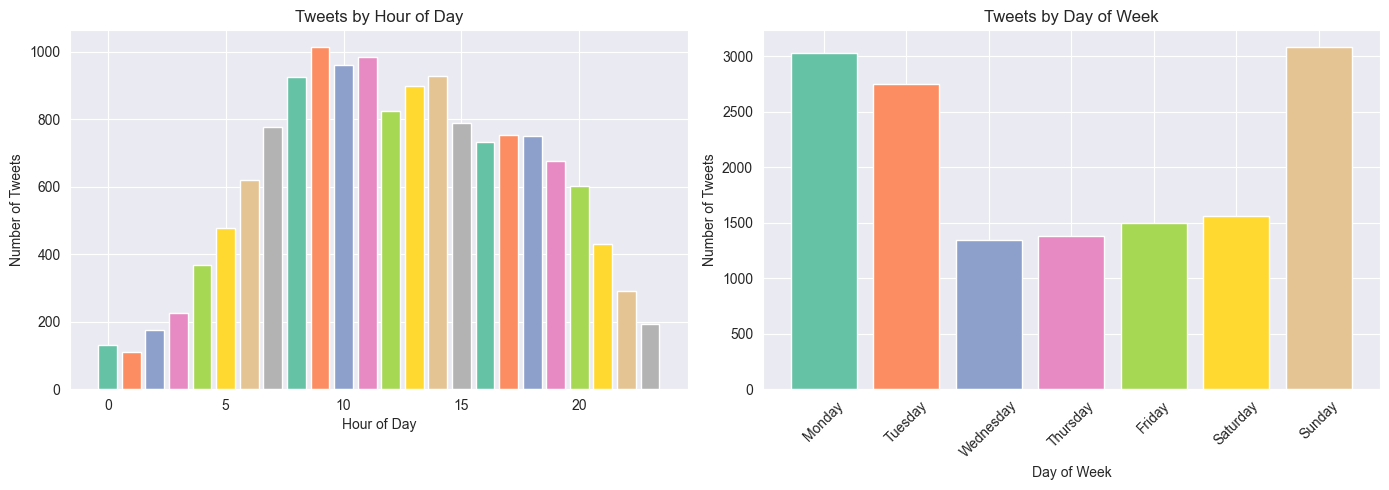

In [10]:
# Let's plot the tweets by hour and by day of week

hourly_tweets = df.groupby('hour').size()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_tweets = df.groupby('day_of_week').size().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Tweets by hour
axes[0].bar(hourly_tweets.index, hourly_tweets.values, color = colors)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Tweets')
axes[0].set_title('Tweets by Hour of Day')

# Tweets by day of week
axes[1].bar(weekly_tweets.index, weekly_tweets.values, color = colors)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Tweets')
axes[1].set_title('Tweets by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

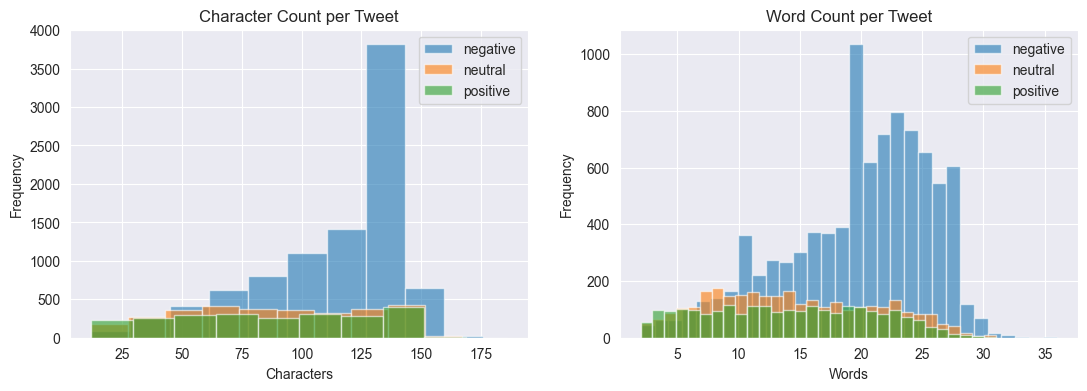

In [11]:
# Now it's time to analyze the tweet's length

df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sent, grp in df.groupby('airline_sentiment'):
    axes[0].hist(grp['char_count'], alpha=0.6, label = sent)
    axes[1].hist(grp['word_count'], bins=30, alpha=0.6, label=sent)

axes[0].set_title('Character Count per Tweet')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count per Tweet')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.show()

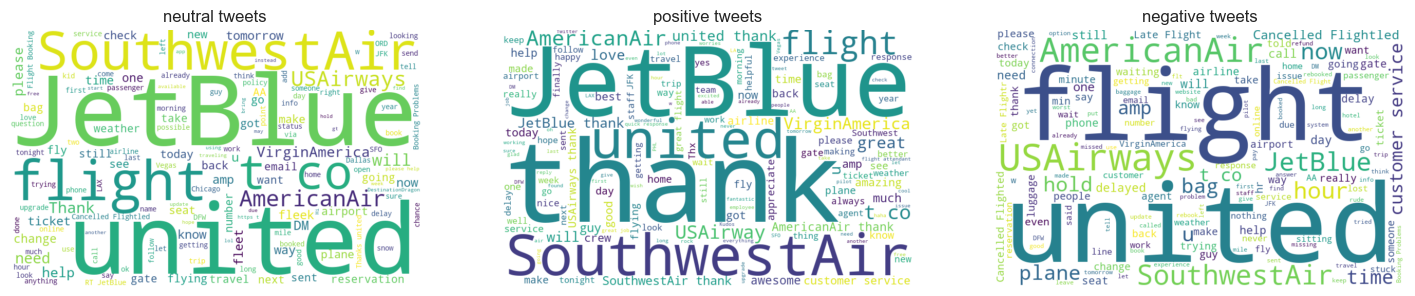

In [12]:


fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, sent in zip(axes, df['airline_sentiment'].unique()):
    text = ' '.join(df[df['airline_sentiment'] == sent]['text'].tolist())
    wc = WordCloud(width = 800, height = 500, background_color = 'white', max_words = 150).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sent} tweets')



## Text Preprocessing

In [13]:
STOP_WORDS = set(stopwords.words('english'))
# Keep negations — they carry strong sentiment signal
NEGATIONS = {'no', 'not', 'nor', 'never', 'neither', "n't"}
STOP_WORDS -= NEGATIONS

lemmatizer = WordNetLemmatizer()

df['clean_text'] = preprocess_corpus(df.text)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop = True)
print(f'Dataset size after cleaning: {len(df)}')

# Let's check some text before and after preprocessing
for _, row in df[['text', 'clean_text']].head(2).iterrows():
    print(f'Before: {row["text"]}')
    print(f'After: {row["clean_text"]}')


Dataset size after cleaning: 14620
Before: @VirginAmerica What @dhepburn said.
After: said
Before: @VirginAmerica plus you've added commercials to the experience... tacky.
After: plus youve added commercial experience tacky


## TF-IDF

In [14]:
# Let's create the labels
le_ann = LabelEncoder()
df['Label'] = le_ann.fit_transform(df['airline_sentiment'])

texts = df['clean_text'].values
labels = df['Label'].values

# Split the data in training and validation set

train_X, temp_X, train_y, temp_y = train_test_split(texts, labels, test_size = 0.2, random_state = 42, stratify = labels)
val_X, test_X, val_y, test_y = train_test_split(temp_X, temp_y, test_size = 0.5, random_state = 42, stratify = temp_y)

del temp_X, temp_y


In [15]:
# Let's vectorize the texts

vector_method = 'tfidf'
train_X_vec, val_X_vec, test_X_vec = vectorize_texts(train_X, val_X, test_X, method = vector_method)


Vectorizing text with TF-IDF


In [16]:
# Let's convert to pytorch tensors

train_X_tensor = torch.tensor(train_X_vec, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.long)

val_X_tensor = torch.tensor(val_X_vec, dtype=torch.float32)
val_y_tensor = torch.tensor(val_y, dtype=torch.long)

test_X_tensor = torch.tensor(test_X_vec, dtype=torch.float32)
test_y_tensor = torch.tensor(test_y, dtype=torch.long)

# Dataloaders
batch_size = 128
train_loader = DataLoader(TensorDataset(train_X_tensor, train_y_tensor), batch_size = batch_size, shuffle = True)
val_loader = DataLoader(TensorDataset(val_X_tensor, val_y_tensor), batch_size = batch_size, shuffle = True)
test_loader = DataLoader(TensorDataset(test_X_tensor, test_y_tensor), batch_size = batch_size, shuffle = True)




## The ANN Modeling

In [50]:
# Hyperparameters

input_dim = train_X_vec.shape[1]
hidden_dim1 = 512
hidden_dim2 = 256
hidden_dim3 = 128
output_dim = len(le_ann.classes_)

device = 'cpu'
model = ANN(input_dim, hidden_dim1, hidden_dim2, hidden_dim3, output_dim, dropout_p1 = 0.4, dropout_p2 = 0.3, dropout_p3 = 0.2)
model.to(device)

class_weights = compute_class_weight('balanced', classes = np.unique(train_y), y = train_y)
weight_tensor = torch.tensor(class_weights, dtype = torch.float32).to(device)

loss_function = nn.CrossEntropyLoss(weight = weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0005, weight_decay = 0.0005)


In [51]:
num_epochs = 200
patience = 7

model, train_losses, val_losses, train_accuracies, val_accuracies  = train_model(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = loss_function,
    optimizer = optimizer,
    num_epochs = num_epochs,
    patience = patience )

Epoch [1/200] | Train Loss: 0.7779 | Val Loss: 0.6996 | Train Acc: 0.6612 | Val Acc: 0.7613
Model improved. Saved to checkpoints/best_model.pt
Epoch [2/200] | Train Loss: 0.3520 | Val Loss: 0.8169 | Train Acc: 0.8836 | Val Acc: 0.7476
Epoch [3/200] | Train Loss: 0.1714 | Val Loss: 0.9686 | Train Acc: 0.9531 | Val Acc: 0.7435
Epoch [4/200] | Train Loss: 0.1012 | Val Loss: 1.1396 | Train Acc: 0.9734 | Val Acc: 0.7524
Epoch [5/200] | Train Loss: 0.0793 | Val Loss: 1.2387 | Train Acc: 0.9804 | Val Acc: 0.7449
Epoch [6/200] | Train Loss: 0.0649 | Val Loss: 1.3640 | Train Acc: 0.9833 | Val Acc: 0.7469
Epoch [7/200] | Train Loss: 0.0585 | Val Loss: 1.5082 | Train Acc: 0.9850 | Val Acc: 0.7449
Epoch [8/200] | Train Loss: 0.0565 | Val Loss: 1.4521 | Train Acc: 0.9844 | Val Acc: 0.7435
Early stopping


## Loss Curve

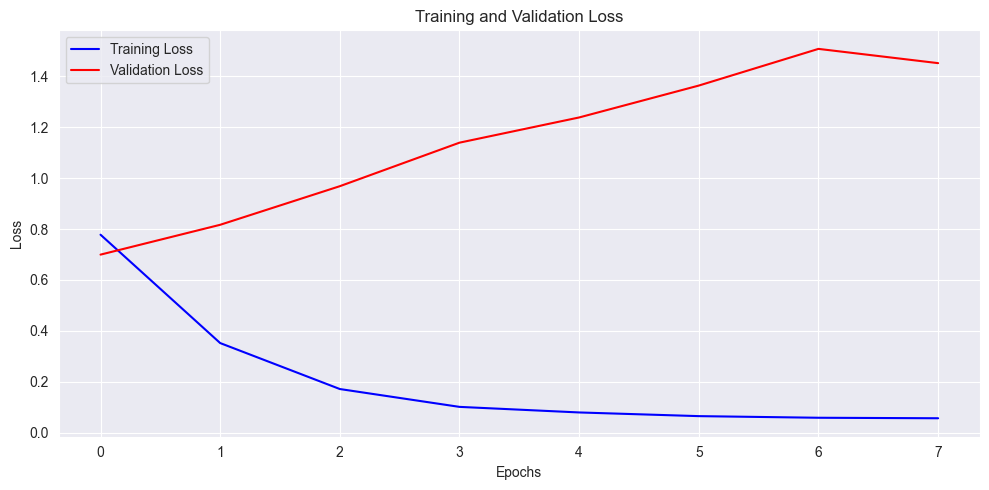

In [52]:
plot_losses(train_losses, val_losses, figsize = (10, 5), show_plot = True)

## Evaluation on Test data

In [53]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = 100.0 * (all_preds == all_labels).mean()
print(f'The accuracy in test data is: {accuracy:.2f}%')

print('Classification report of test data:')
print(classification_report(all_labels, all_preds, target_names=le_ann.classes_))

The accuracy in test data is: 79.21%
Classification report of test data:
              precision    recall  f1-score   support

    negative       0.88      0.85      0.86       917
     neutral       0.62      0.63      0.63       309
    positive       0.71      0.76      0.73       236

    accuracy                           0.79      1462
   macro avg       0.74      0.75      0.74      1462
weighted avg       0.80      0.79      0.79      1462



## Confusion Matrix

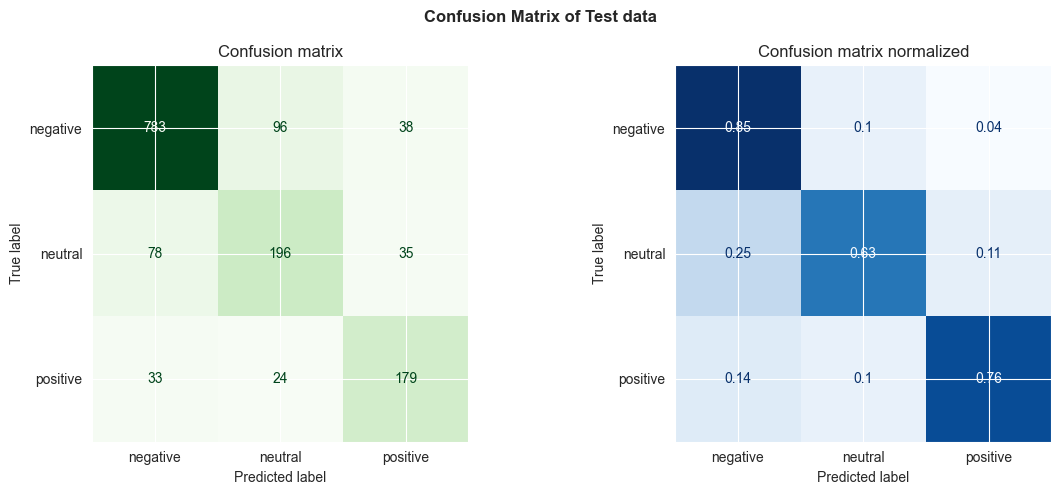

In [54]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis = 1, keepdims = True)

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

ConfusionMatrixDisplay(cm, display_labels = le_ann.classes_).plot( ax = axes[0], colorbar = False, cmap = 'Greens')
axes[0].set_title('Confusion matrix')

ConfusionMatrixDisplay(cm_normalized.round(2), display_labels = le_ann.classes_).plot( ax = axes[1], colorbar = False, cmap = 'Blues')
axes[1].set_title('Confusion matrix normalized')

plt.suptitle('Confusion Matrix of Test data', fontweight='bold')
plt.tight_layout()
plt.show()

## Comparison
#### Let's compare the TF-IDF results with the Word2Vec and FastText

In [57]:

train_tokens = [tokenize(text) for text in train_X]

# Word2Vec training
w2v_model = Word2Vec( sentences = train_tokens, vector_size = 300, window = 5, min_count = 2, workers = 4, epochs = 10)

def tweet_to_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

vector_size = 300
train_X_w2v = np.array([tweet_to_vector(tokenize(t), w2v_model, vector_size) for t in train_X])
val_X_w2v   = np.array([tweet_to_vector(tokenize(t), w2v_model, vector_size) for t in val_X])
test_X_w2v  = np.array([tweet_to_vector(tokenize(t), w2v_model, vector_size) for t in test_X])




# FastText training
ft_model = FastText(sentences = train_tokens, vector_size = 300, window = 5, min_count = 2, workers = 4, epochs = 10)

train_X_ft = np.array([tweet_to_vector(tokenize(t), ft_model, vector_size) for t in train_X])
val_X_ft   = np.array([tweet_to_vector(tokenize(t), ft_model, vector_size) for t in val_X])
test_X_ft  = np.array([tweet_to_vector(tokenize(t), ft_model, vector_size) for t in test_X])


input_dim = train_X_w2v.shape[1]
train_X_tensor = torch.tensor(train_X_w2v, dtype=torch.float32)
val_X_tensor   = torch.tensor(val_X_w2v,   dtype=torch.float32)
test_X_tensor  = torch.tensor(test_X_ft,   dtype=torch.float32)



results = {}

for method_name, (tr, va, te) in [ ('TF-IDF',    (train_X_vec, val_X_vec, test_X_vec)), ('Word2Vec',  (train_X_w2v, val_X_w2v, test_X_w2v)), ('FastText',  (train_X_ft,  val_X_ft,  test_X_ft))]:
    print(f'{method_name}')

    input_dim = tr.shape[1]
    model = ANN(input_dim, 512, 256, 128, output_dim).to(device)

    class_weights   = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    weight_tensor   = torch.tensor(class_weights, dtype=torch.float32).to(device)
    loss_function   = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer       = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0005)

    train_loader = DataLoader(TensorDataset(torch.tensor(tr, dtype=torch.float32),
                                            torch.tensor(train_y, dtype=torch.long)),
                              batch_size=128, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.tensor(va, dtype=torch.float32),
                                            torch.tensor(val_y, dtype=torch.long)),
                              batch_size=128, shuffle=False)
    test_loader  = DataLoader(TensorDataset(torch.tensor(te, dtype=torch.float32),
                                            torch.tensor(test_y, dtype=torch.long)),
                              batch_size=128, shuffle=False)

    model, *_ = train_model(model, train_loader, val_loader, loss_function, optimizer,
                            num_epochs=200, patience=7)

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).mean()
    results[method_name] = acc
    print(f'Test Accuracy: {acc:.2f}%')
    print(classification_report(all_labels, all_preds, target_names=le_ann.classes_))

# All the results
for method, acc in results.items():
    print(f'{method:10s}: {acc:.2f}%')

TF-IDF
Epoch [1/200] | Train Loss: 0.7848 | Val Loss: 0.6950 | Train Acc: 0.6549 | Val Acc: 0.7763
Model improved. Saved to checkpoints/best_model.pt
Epoch [2/200] | Train Loss: 0.3546 | Val Loss: 0.7575 | Train Acc: 0.8817 | Val Acc: 0.7558
Epoch [3/200] | Train Loss: 0.1678 | Val Loss: 0.9694 | Train Acc: 0.9531 | Val Acc: 0.7462
Epoch [4/200] | Train Loss: 0.1011 | Val Loss: 1.1667 | Train Acc: 0.9764 | Val Acc: 0.7524
Epoch [5/200] | Train Loss: 0.0719 | Val Loss: 1.2813 | Train Acc: 0.9812 | Val Acc: 0.7565
Epoch [6/200] | Train Loss: 0.0621 | Val Loss: 1.3217 | Train Acc: 0.9858 | Val Acc: 0.7442
Epoch [7/200] | Train Loss: 0.0577 | Val Loss: 1.3720 | Train Acc: 0.9861 | Val Acc: 0.7524
Epoch [8/200] | Train Loss: 0.0511 | Val Loss: 1.4382 | Train Acc: 0.9862 | Val Acc: 0.7572
Early stopping
Test Accuracy: 79.34%
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87       917
     neutral       0.59      0.66      0.62       309
    po


## Results

- There is an accuracy score around 80%
- The TF-IDF performed better than Word2Vec and FastText
- There was a significant imbalance in classes, but the class weighting seems to worked well
- It seems that Neutral class was the hardest to predict
- The negatives achieved a 86% F1, and the model learned this class probably because of the comments were negative
- The model could also fairly predict the positives
- As for the Loss curve we can see the training loss droped to 0 by epoch 3-4
- The training and validation curves separate at the beginning and the model started to overfit from the first epochs




